# Predictive Maintenance using Contextual Data Fusion

## Project Objective

Develop a predictive maintenance framework that combines:

- Internal IoT telemetry
- External environmental context

to predict machine failures before they occur.

### Business Goal

Reduce unplanned downtime and maintenance cost by transitioning from reactive maintenance to predictive maintenance.

## Dataset

AI4I 2020 Predictive Maintenance Dataset

Contains:

- Air temperature
- Process temperature
- Rotational speed
- Torque
- Tool wear
- Failure indicators

The dataset simulates real-world industrial machine operations.

## Week 1 Goals

1. Load dataset
2. Inspect data quality
3. Perform exploratory analysis
4. Generate rolling statistical features
5. Build baseline telemetry dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", None)

plt.style.use("default")

print("All libraries loaded successfully.")

All libraries loaded successfully.


# Data Loading and Initial Exploration

The objective of this section is to:

- Load the AI4I Predictive Maintenance Dataset
- Inspect its structure
- Check for missing values
- Understand class imbalance
- Identify features available for predictive maintenance modeling

In [2]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.shape

Rows: 10000
Columns: 14


(10000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

## Feature Description

| Feature | Description |
|----------|------------|
| Air temperature | Ambient operating temperature |
| Process temperature | Internal process temperature |
| Rotational speed | RPM of machine |
| Torque | Applied torque |
| Tool wear | Tool wear duration |
| Machine failure | Target variable |

In [5]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [7]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [8]:
failure_rate = df["Machine failure"].mean() * 100

print(f"Failure Rate: {failure_rate:.2f}%")

Failure Rate: 3.39%


## Class Imbalance Observation

Machine failures represent a very small portion of total observations.

This imbalance makes predictive maintenance challenging because standard machine learning models tend to favor the majority class.

In later stages, SMOTE will be applied only within training folds during cross-validation to avoid data leakage.

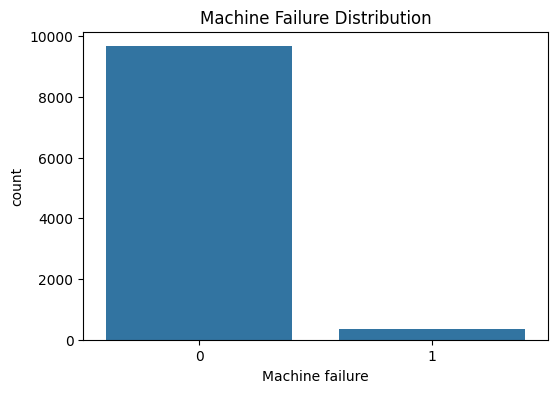

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Machine failure")

plt.title("Machine Failure Distribution")
plt.show()

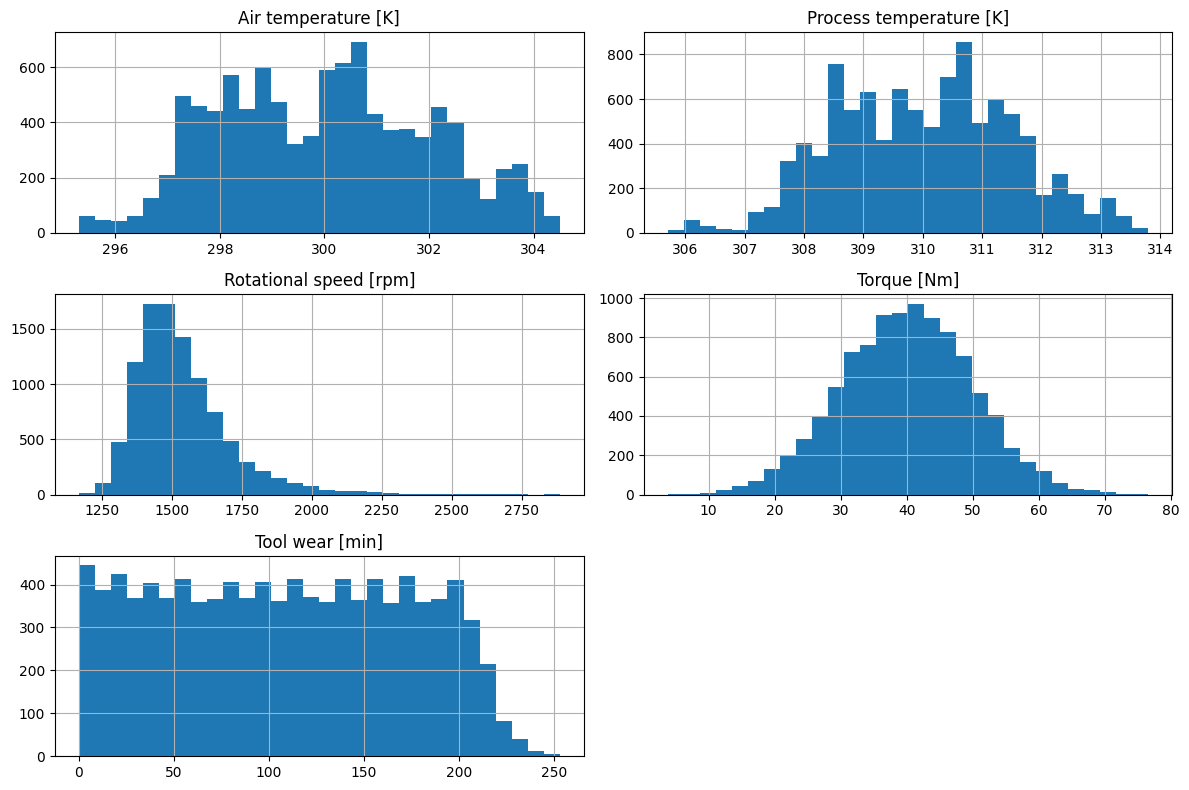

In [10]:
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

df[sensor_cols].hist(figsize=(12, 8), bins=30)

plt.tight_layout()
plt.show()

## Correlation Analysis

Understanding relationships among telemetry signals helps identify redundant features and potential predictive indicators.

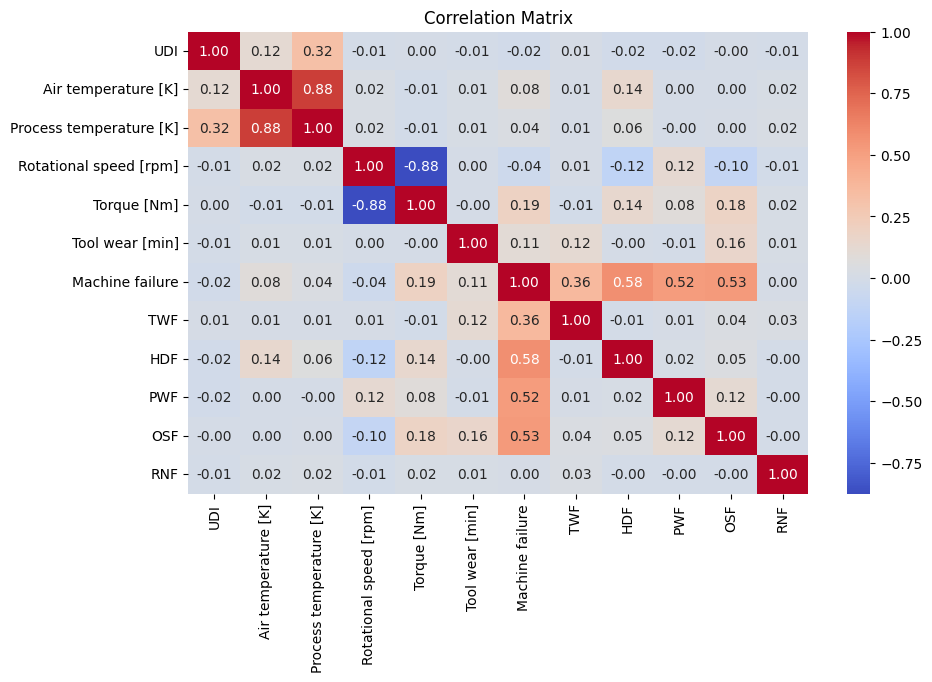

In [11]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

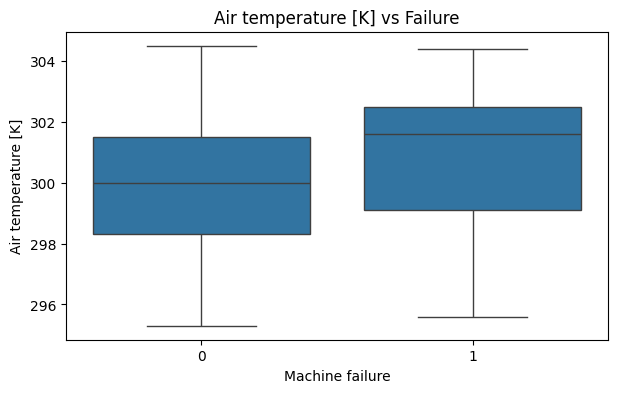

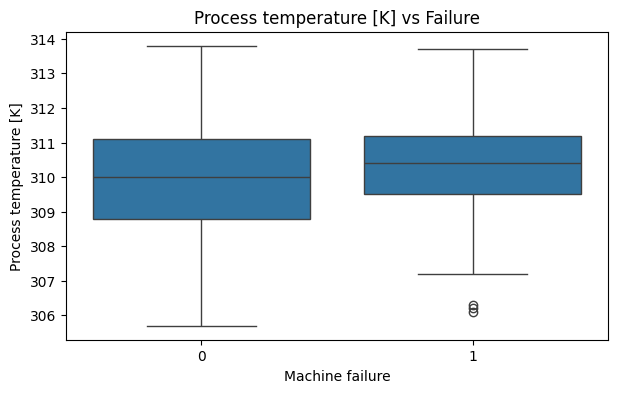

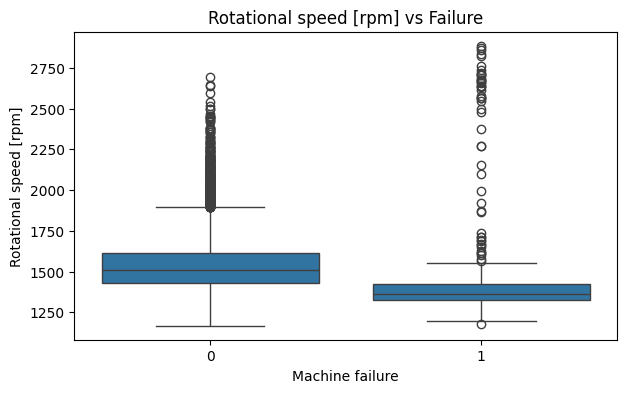

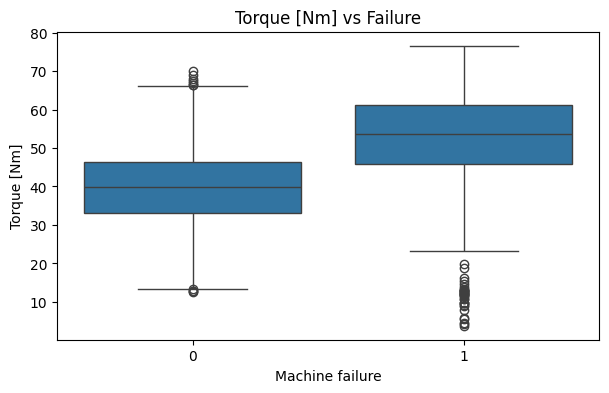

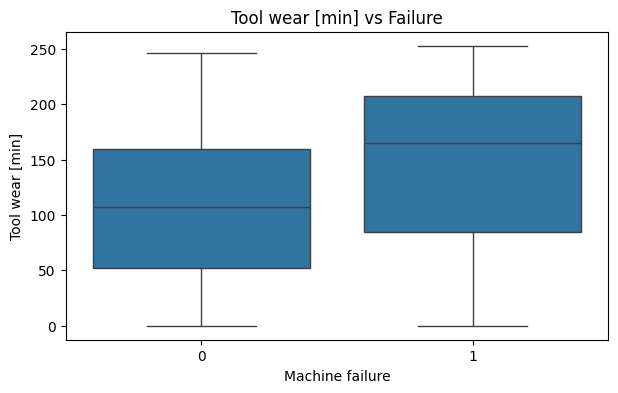

In [12]:
for col in sensor_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(data=df, x="Machine failure", y=col)

    plt.title(f"{col} vs Failure")

    plt.show()

# Telemetry Signal Processing

Raw sensor values often do not capture operational trends.

Industrial predictive maintenance systems typically use rolling statistics and lag-based features to capture machine behavior over time.

In this section, we create:

- Rolling Mean
- Rolling Standard Deviation
- Rolling Variance
- Lag Features
- Temperature Difference Features

In [13]:
telemetry_df = df.copy()

display(telemetry_df.head())

df.shape

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


(10000, 14)

In [14]:
telemetry_df = telemetry_df.sort_values("UDI")

telemetry_df.reset_index(drop=True, inplace=True)

telemetry_df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [15]:
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

## Rolling Mean Features

Rolling averages smooth short-term fluctuations and reveal longer-term trends in machine behavior.

In [16]:
window_size = 10

for col in sensor_cols:

    telemetry_df[f"{col}_roll_mean"] = (
        telemetry_df[col].rolling(window=window_size).mean()
    )

## Rolling Standard Deviation Features

Sudden increases in variability often indicate instability or degradation.

In [17]:
for col in sensor_cols:

    telemetry_df[f"{col}_roll_std"] = (
        telemetry_df[col].rolling(window=window_size).std()
    )

In [18]:
for col in sensor_cols:

    telemetry_df[f"{col}_roll_var"] = (
        telemetry_df[col].rolling(window=window_size).var()
    )

## Lag Features

Lag variables help models understand how current readings differ from previous operational states.

In [19]:
for col in sensor_cols:

    telemetry_df[f"{col}_lag1"] = telemetry_df[col].shift(1)

    telemetry_df[f"{col}_lag2"] = telemetry_df[col].shift(2)

In [20]:
telemetry_df["temp_difference"] = (
    telemetry_df["Process temperature [K]"] - telemetry_df["Air temperature [K]"]
)

## Rate of Change Features

Abrupt changes in sensor readings often precede mechanical failures.

In [21]:
for col in sensor_cols:

    telemetry_df[f"{col}_change"] = telemetry_df[col].diff()

In [22]:
telemetry_df.shape

(10000, 45)

In [23]:
telemetry_df.isnull().sum().sort_values(ascending=False).head(20)

Torque [Nm]_roll_var                 9
Air temperature [K]_roll_var         9
Tool wear [min]_roll_std             9
Torque [Nm]_roll_std                 9
Process temperature [K]_roll_var     9
Rotational speed [rpm]_roll_std      9
Process temperature [K]_roll_std     9
Tool wear [min]_roll_mean            9
Air temperature [K]_roll_std         9
Torque [Nm]_roll_mean                9
Rotational speed [rpm]_roll_mean     9
Process temperature [K]_roll_mean    9
Air temperature [K]_roll_mean        9
Tool wear [min]_roll_var             9
Rotational speed [rpm]_roll_var      9
Tool wear [min]_lag2                 2
Rotational speed [rpm]_lag2          2
Torque [Nm]_lag2                     2
Process temperature [K]_lag2         2
Air temperature [K]_lag2             2
dtype: int64

In [24]:
telemetry_df = telemetry_df.dropna()

telemetry_df.shape

(9991, 45)

In [25]:
telemetry_df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Air temperature [K]_roll_mean,Process temperature [K]_roll_mean,Rotational speed [rpm]_roll_mean,Torque [Nm]_roll_mean,Tool wear [min]_roll_mean,Air temperature [K]_roll_std,Process temperature [K]_roll_std,Rotational speed [rpm]_roll_std,Torque [Nm]_roll_std,Tool wear [min]_roll_std,Air temperature [K]_roll_var,Process temperature [K]_roll_var,Rotational speed [rpm]_roll_var,Torque [Nm]_roll_var,Tool wear [min]_roll_var,Air temperature [K]_lag1,Air temperature [K]_lag2,Process temperature [K]_lag1,Process temperature [K]_lag2,Rotational speed [rpm]_lag1,Rotational speed [rpm]_lag2,Torque [Nm]_lag1,Torque [Nm]_lag2,Tool wear [min]_lag1,Tool wear [min]_lag2,temp_difference,Air temperature [K]_change,Process temperature [K]_change,Rotational speed [rpm]_change,Torque [Nm]_change,Tool wear [min]_change
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0,298.19,308.66,1521.6,39.91,10.4,0.128668,0.134990,113.060652,6.826655,6.834553,0.016556,0.018222,12782.711111,46.603222,46.711111,298.3,298.1,308.7,308.6,1667.0,1527.0,28.6,40.2,18.0,16.0,10.5,0.2,0.3,74.0,-0.6,3.0
10,11,H29424,H,298.4,308.9,1782,23.9,24,0,0,0,0,0,0,298.22,308.69,1544.7,38.02,12.8,0.139841,0.152388,140.100004,8.377722,6.988880,0.019556,0.023222,19628.011111,70.186222,48.844444,298.5,298.3,309.0,308.7,1741.0,1667.0,28.0,28.6,21.0,18.0,10.5,-0.1,-0.1,41.0,-4.1,3.0
11,12,H29425,H,298.6,309.1,1423,44.3,29,0,0,0,0,0,0,298.26,308.73,1546.2,37.82,15.4,0.183787,0.200278,138.545460,8.179622,7.734483,0.033778,0.040111,19194.844444,66.906222,59.822222,298.4,298.5,308.9,309.0,1782.0,1741.0,23.9,28.0,24.0,21.0,10.5,0.2,0.2,-359.0,20.4,5.0
12,13,M14872,M,298.6,309.1,1339,51.1,34,0,0,0,0,0,0,298.31,308.79,1530.3,37.99,18.3,0.202485,0.213177,153.055582,8.459899,8.769265,0.041000,0.045444,23426.011111,71.569889,76.900000,298.6,298.4,309.1,308.9,1423.0,1782.0,44.3,23.9,29.0,24.0,10.5,0.0,0.0,-84.0,6.8,5.0
13,14,M14873,M,298.6,309.2,1742,30.0,37,0,0,0,0,0,0,298.35,308.85,1561.2,37.04,21.3,0.217307,0.236878,162.150684,8.798131,9.569047,0.047222,0.056111,26292.844444,77.407111,91.566667,298.6,298.6,309.1,309.1,1339.0,1423.0,51.1,44.3,34.0,29.0,10.6,0.0,0.1,403.0,-21.1,3.0


## Saving Processed Dataset

The engineered telemetry dataset will be used for contextual fusion and machine learning in subsequent stages.

In [26]:
telemetry_df.to_csv("../data/processed/telemetry_features.csv", index=False)

print("Saved successfully.")

Saved successfully.


## Conclusion

The AI4I dataset was successfully ingested and analyzed. Initial exploratory analysis confirmed good data quality and revealed an imbalanced target distribution, motivating subsequent feature engineering and predictive modeling.